![](leaderboard.png)

In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import *
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

## Загрузка данных

In [2]:
dataset_raw = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
dataset_raw = dataset_raw.drop([0, 1, 2, 3, 504], axis=1)
dataset_raw.columns = list(range(500))
dataset_raw.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [3]:
dataset_raw.shape

(23479, 500)

Датасет без преобразования выглядит так:

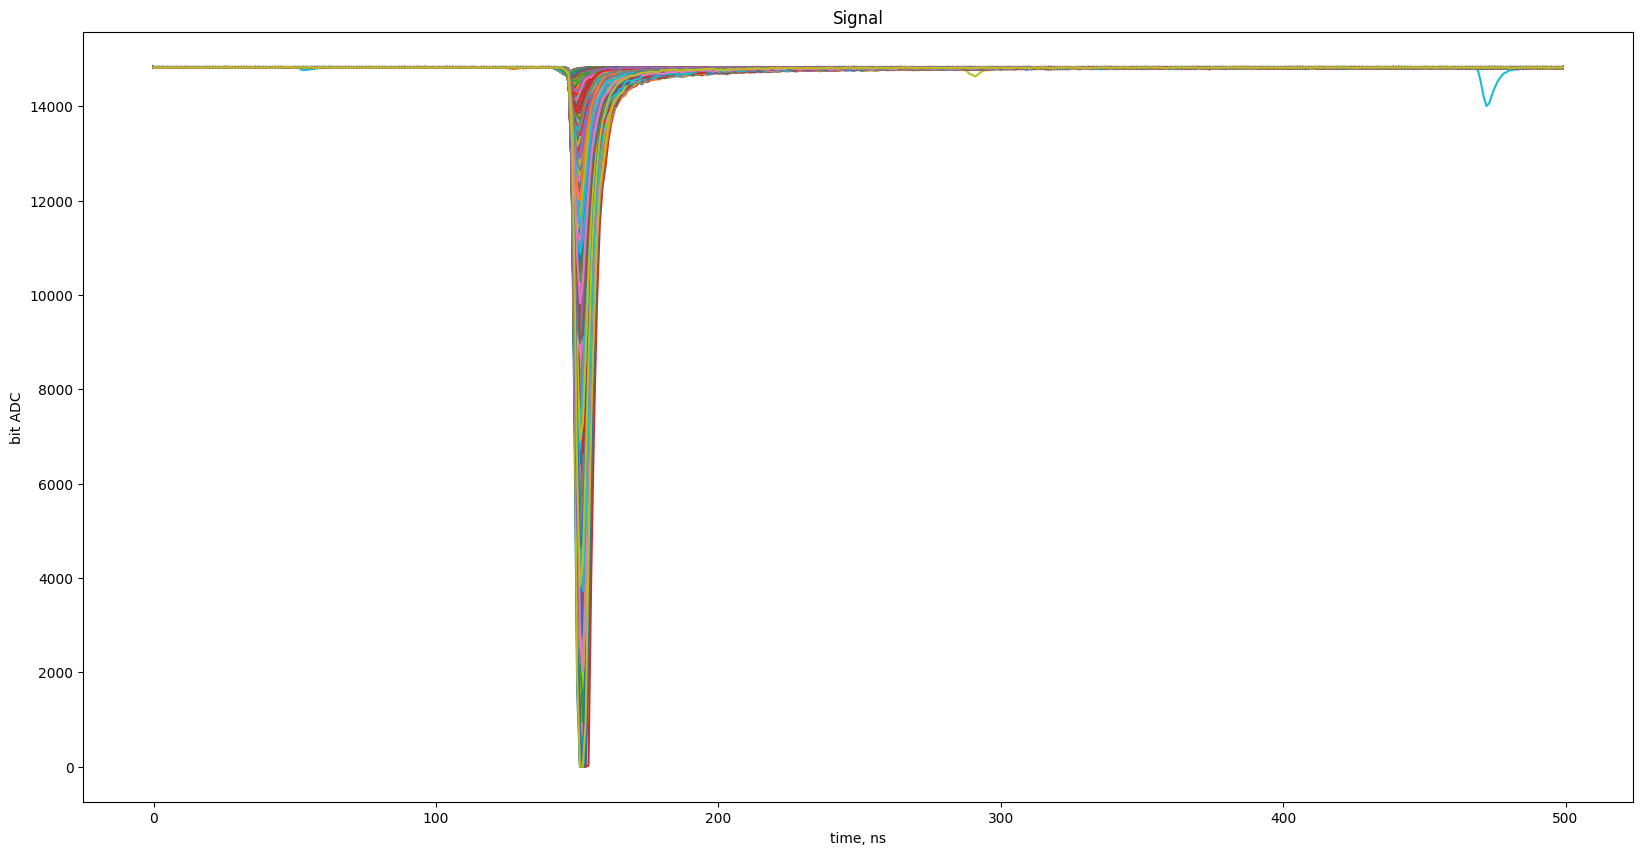

In [3]:
ax = dataset_raw.loc[:].T.plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")
plt.show()

## Подготовка данных

"Переворачиваю" импульсы

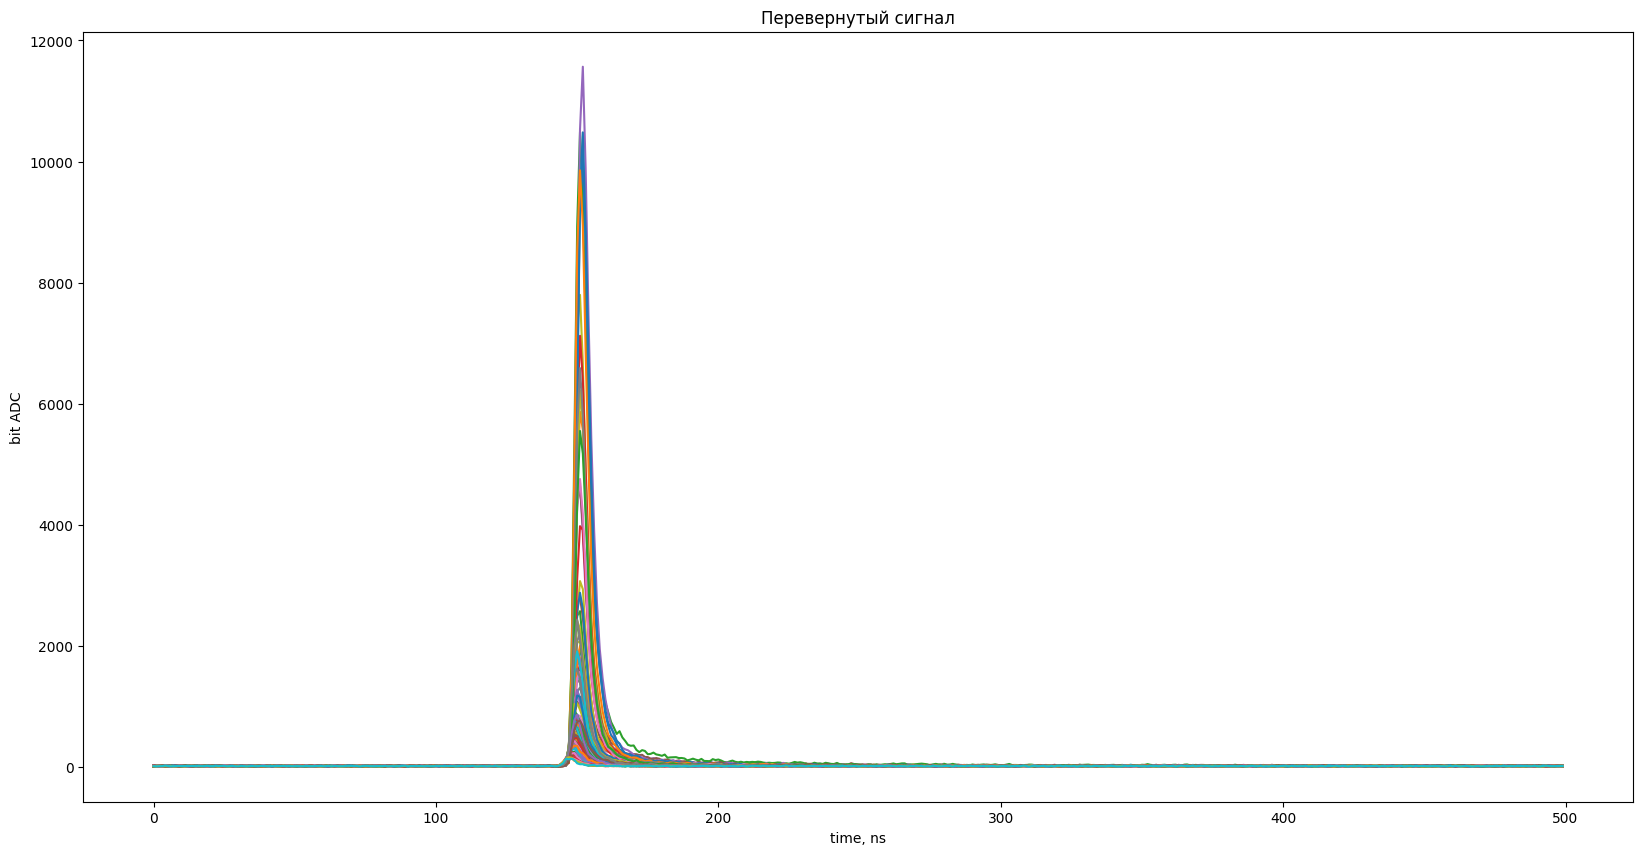

In [4]:
max_val = dataset_raw.max().max()
dataset_inverted = (dataset_raw * -1) + max_val
ax = dataset_inverted.loc[:].T[range(100)].plot(title='Перевернутый сигнал' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")
plt.show()

## Генерация признаков

Собираю информацию о шуме на участке без импульса -- первых 100 наблюдениях

In [5]:
noize = dataset_inverted.loc[:, :100].mean(axis=1)
noize_std = dataset_inverted.loc[:, :100].std(axis=1)

Получаю точную высоту пика

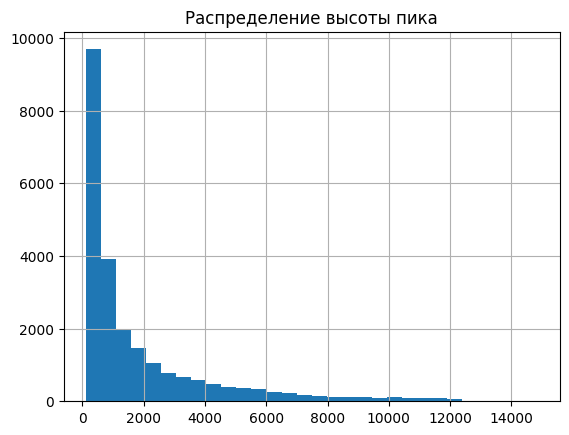

In [6]:
peak_height = dataset_inverted.max(axis=1)
plt.title("Распределение высоты пика")
peak_height.hist(bins=30)
plt.show()

Нахожу точку, в которой пик находится. Как правило, это 150, но иногда немного раньше

In [7]:
peak_indices = []
for i in range(len(dataset_inverted)):
    row = dataset_inverted.loc[i, :]
    for j in range(152):
        if row[j] == peak_height[i]:
            peak_indices += [j]
            break
    else:
        peak_indices += [152]
            
peak_point = pd.Series(peak_indices)
peak_point.describe()

count    23479.000000
mean       149.614975
std          1.331810
min        145.000000
25%        149.000000
50%        150.000000
75%        151.000000
max        152.000000
dtype: float64

Выделяю конец пика. Считаю, что пик "заканчивается" тогда, когда снято наблюдение, не превышающее средний уровень шума до пика + стандартное отклонение

count    23479.000000
mean       203.388219
std         40.655330
min        154.000000
25%        172.000000
50%        190.000000
75%        225.000000
max        443.000000
dtype: float64


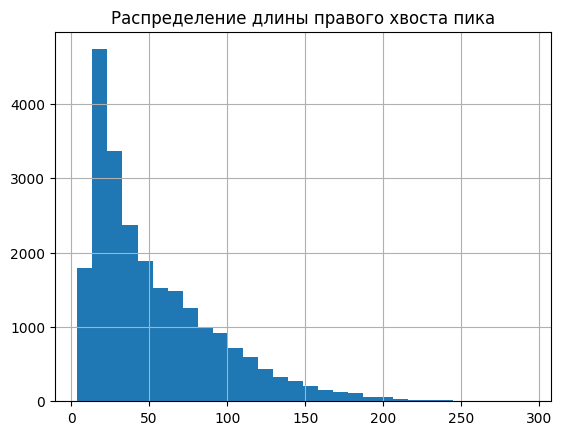

In [14]:
peak_end_indices = []
for i in range(len(dataset_inverted)):
    row = dataset_inverted.loc[i, :]
    for j in range(150, 500):
        if row[j] <= noize[i] + noize_std[i]:
            peak_end_indices += [j]
            break
    else:
        peak_end_indices += [499]
peak_end = pd.Series(peak_end_indices)
print(peak_end.describe())
plt.title("Распределение длины правого хвоста пика")
(peak_end - 150).hist(bins=30)
plt.show()

Выделяю индекс, с которого начинается левый хвост пика. Как правило, этот хвост очень короткий

count    23479.000000
mean       143.398569
std          1.051089
min        135.000000
25%        143.000000
50%        144.000000
75%        144.000000
max        146.000000
dtype: float64


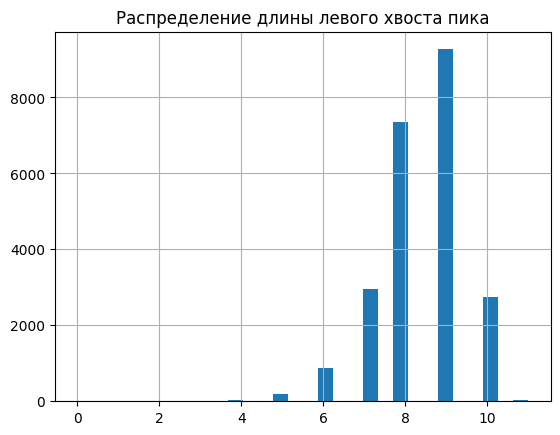

In [16]:
peak_start_indices = []
for i in range(len(dataset_inverted)):
    row = dataset_inverted.loc[i, :]
    for j in range(150, 0, -1):
        if row[j] <= noize[i] + noize_std[i]:
            peak_start_indices += [j]
            break
    else:
        peak_start_indices += [150]
peak_start = pd.Series(peak_start_indices)
print(peak_start.describe())
plt.title("Распределение длины левого хвоста пика")
(peak_start - peak_start.min()).hist(bins=30)
plt.show()

Считаю ширину пика и соотношение ширины и высоты. Минимальная ширина пика -- 12 наблюдений

In [25]:
peak_width = peak_end - peak_start
width_to_height = peak_width / peak_height
peak_width.min()

np.int64(12)

#### Расчет PSD

Считаю площадь для всего пика и для короткого периода -- 11 наблюдений, минимальная ширина пика - 1

In [26]:
short_period_sum = []
long_period_sum = []
for i in range(len(dataset_inverted)):
    row = dataset_inverted.loc[i, :]
    short_period_sum += [row[peak_start[i]:peak_indices[i] + 11].sum()]
    long_period_sum += [row[peak_start[i]:peak_end_indices[i]].sum()]
long_period_area = pd.Series(long_period_sum)
short_period_area = pd.Series(short_period_sum)

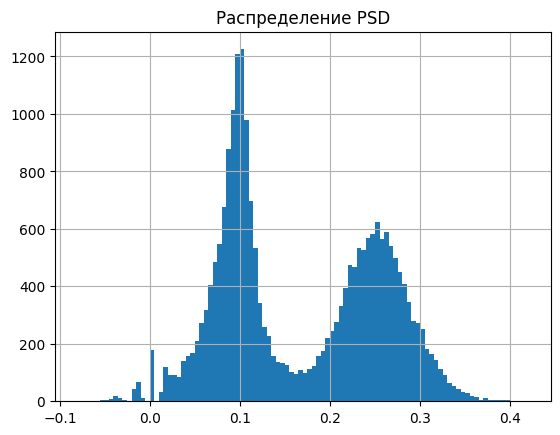

In [29]:
psd = (long_period_area - short_period_area) / long_period_area
plt.title("Распределение PSD")
psd.hist(bins=100)
plt.show()

#### Формирование датасета

В финальный датасет не беру изначальный набор данных, а только расчетные признаки:
- PSD
- Общая площадь пика (она же в нашем случае long)
- Ширина пика
- Высота пика

In [31]:
data = pd.DataFrame([pds, long_period_area, peak_width, peak_height]).T
data.columns = ["pds", "total_area", "peak_width", "peak_height"]

Визуализация признаков. Уже на основе нее можно понять, как примерно будет выглядеть деление на 3 кластера

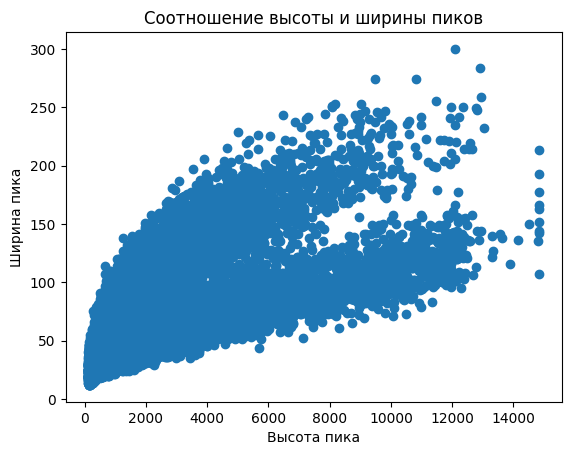

In [34]:
plt.title("Соотношение высоты и ширины пиков")
plt.scatter(data["peak_height"], data["peak_width"])
plt.xlabel("Высота пика")
plt.ylabel("Ширина пика")
plt.show()

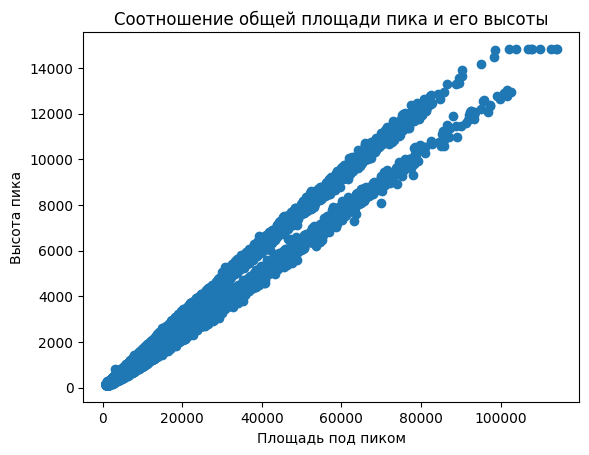

In [35]:
plt.title("Соотношение общей площади пика и его высоты")
plt.scatter(data["total_area"], data["peak_height"])
plt.xlabel("Площадь под пиком")
plt.ylabel("Высота пика")
plt.show()

### Обучение модели

#### Подход 1: StandardScaler + PCA + ручное разделение кластеров

Применила StandardScaler, выделила 2 компоненты с помощью метода главных компонент. На визуализации с ними видно, как кластера можно попробовать разделить прямыми

In [37]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

pca_2 = PCA(2)
data_pca_2_np = pca_2.fit_transform(data_scaled)
data_pca_2 = pd.DataFrame(data_pca_2_np, columns=["PCA1", "PCA2"])

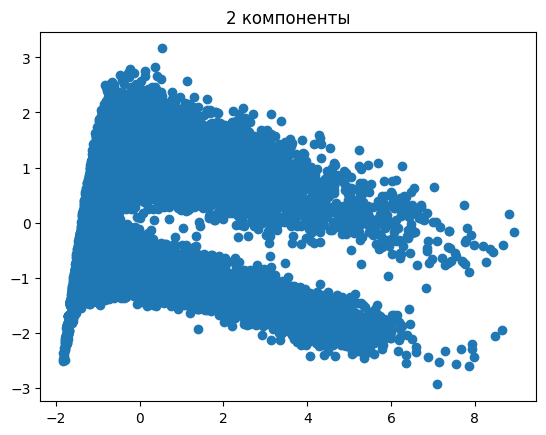

In [39]:
plt.title("2 компоненты")
plt.scatter(data_pca_2["PCA1"], data_pca_2["PCA2"])
plt.show()

In [83]:
data_pca_2["label_1"] = (data_pca_2["PCA1"] < data_pca_2["PCA2"] * -5).astype("int")
data_pca_2["label_2"] = (data_pca_2["PCA1"] < data_pca_2["PCA2"] * -5 - 11).astype("int")
data_pca_2["label"] = data_pca_2["label_1"] + data_pca_2["label_2"]

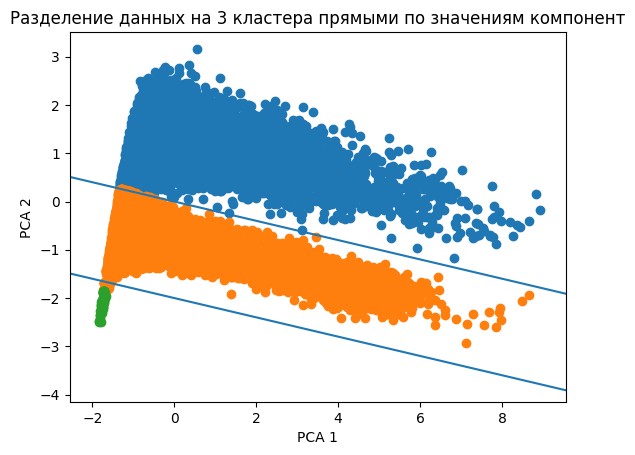

In [84]:
plt.title("Разделение данных на 3 кластера прямыми по значениям компонент")
for i in range(3):
    cluster = data_pca_2[data_pca_2["label"] == i]
    plt.scatter(cluster["PCA1"], cluster["PCA2"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.axline((9, -1.8), (-2, 0.4))
plt.axline((-2, -1.6), (9, -3.8))
plt.show()

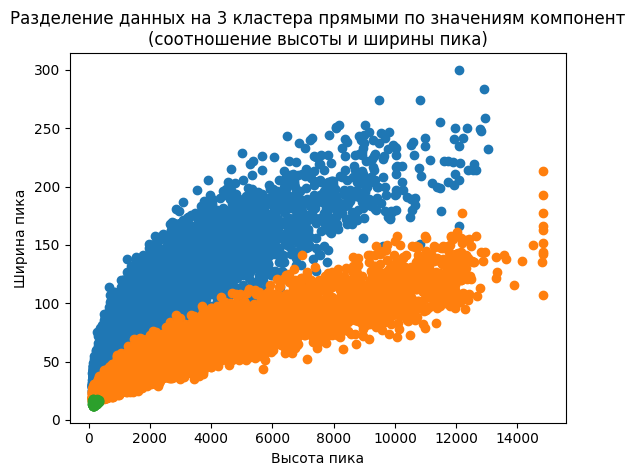

In [63]:
plt.title("Разделение данных на 3 кластера прямыми по значениям компонент\n(соотношение высоты и ширины пика)")
for i in range(3):
    cluster = data[data_pca_2["label"] == i]
    plt.scatter(cluster["peak_height"], cluster["peak_width"])
plt.xlabel("Высота пика")
plt.ylabel("Ширина пика")
plt.show()

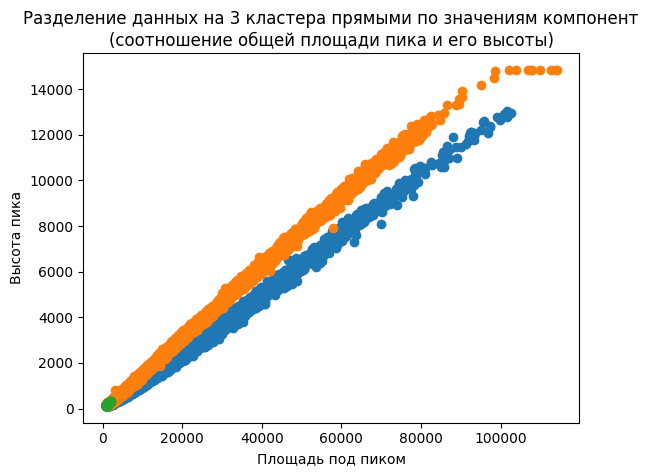

In [65]:
plt.title("Разделение данных на 3 кластера прямыми по значениям компонент\n(cоотношение общей площади пика и его высоты)")
for i in range(3):
    cluster = data[data_pca_2["label"] == i]
    plt.scatter(cluster["total_area"], cluster["peak_height"])
plt.xlabel("Площадь под пиком")
plt.ylabel("Высота пика")
plt.show()

In [80]:
print("Количество наблюдений в кластерах:")
print(data_pca_2.groupby("label")["label"].count())

Количество наблюдений в кластерах:
label
0    10826
1    12299
2      354
Name: label, dtype: int64


#### StandardScaler + PCA + GaussianMixture

Применяю GaussianMixture на преобразованных данных с выделенными главными компонентами

GaussianMixture со стандартным параметром вида матрицы ковариации справляется с задачей плохо. Для улучшения разделения помогает использование параметра covariance_type='tied', но разделение все равно не такое четкое, как при использовании только метода главных компонент

In [67]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

pca = PCA()
data_pca_np = pca.fit_transform(data_scaled)
data_pca = pd.DataFrame(data_pca_np)

data_for_gaussian_mixture = data_pca.copy()
gaussian_mixture = GaussianMixture(n_components=3, random_state=42)
data_for_gaussian_mixture["label"] = gaussian_mixture.fit_predict(data_for_gaussian_mixture)

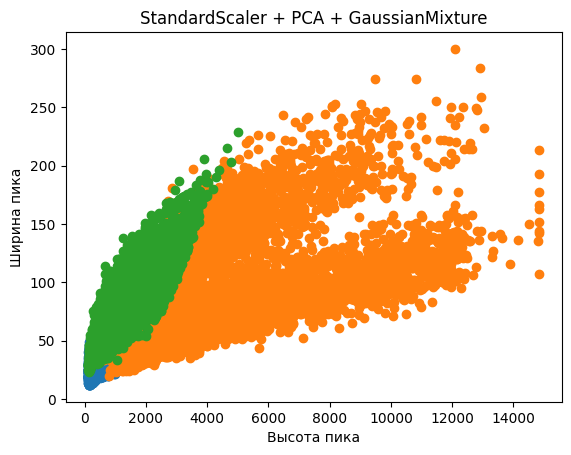

In [68]:
plt.title("StandardScaler + PCA + GaussianMixture")
for i in range(3):
    cluster = data[data_for_gaussian_mixture["label"] == i]
    plt.scatter(cluster["peak_height"], cluster["peak_width"])
plt.xlabel("Высота пика")
plt.ylabel("Ширина пика")
plt.show()

In [69]:
data_for_gaussian_mixture_tied = data_pca.copy()
gaussian_mixture = GaussianMixture(n_components=3, random_state=42, covariance_type="tied")
data_for_gaussian_mixture_tied["label"] = gaussian_mixture.fit_predict(data_for_gaussian_mixture_tied)

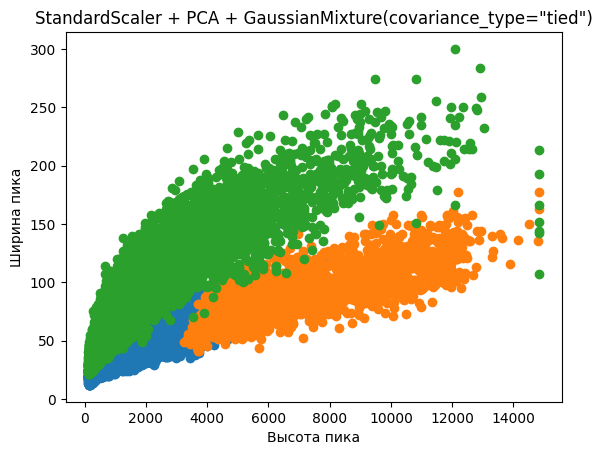

In [70]:
plt.title("StandardScaler + PCA + GaussianMixture(covariance_type=\"tied\")")
for i in range(3):
    cluster = data[data_for_gaussian_mixture_tied["label"] == i]
    plt.scatter(cluster["peak_height"], cluster["peak_width"])
plt.xlabel("Высота пика")
plt.ylabel("Ширина пика")
plt.show()

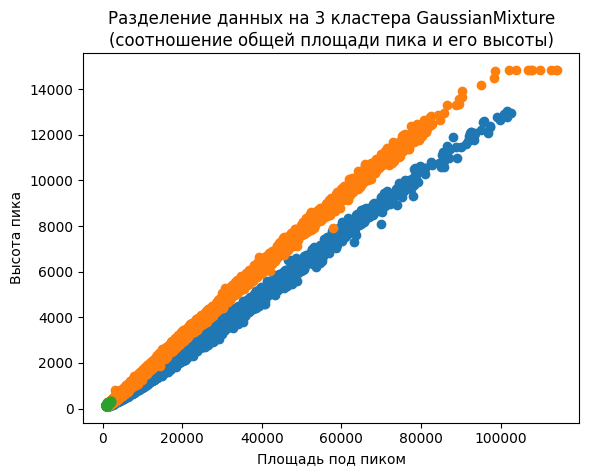

In [71]:
plt.title("Разделение данных на 3 кластера GaussianMixture\n(cоотношение общей площади пика и его высоты)")
for i in range(3):
    cluster = data[data_pca_2["label"] == i]
    plt.scatter(cluster["total_area"], cluster["peak_height"])
plt.xlabel("Площадь под пиком")
plt.ylabel("Высота пика")
plt.show()

### Формирование результата

Визуально лучший результат показало использование метода главных компонент и разделение кластеров прямыми. При таком способе кластер с выбросамо получается небольшим

In [85]:
clustered_data = data_pca_2

In [86]:
# df0 = pd.DataFrame(pd.Series(kmeans.labels_), columns=["label"])
clustered_data['cluster'] = -1
i = 0
for lbl in pd.Series(clustered_data["label"]).unique():
    clustered_data.loc[clustered_data['label'] == lbl, 'cluster'] = i
    i += 1
clustered_data.index.name = 'index'
clustered_data["cluster"].to_csv(f"pca_visual.csv")